# Model 4: Genre & Keywords → Revenue

Bayesian linear regression with ARD-style priors over genre one-hots and keyword topic features.  
Output: posterior predictive **N(μ_genre, σ_genre²)** over log-revenue per movie.

Pipeline:
1. Load movies + keywords
2. Parse keywords → TF-IDF → SVD topics
3. Build feature matrix: genres + topics + runtime
4. Pyro model with group-level ARD priors
5. SVI training
6. Posterior predictive → (μ, σ) per movie

## 1. Imports & Settings

In [1]:
pip install pyro-ppl

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import ast
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer   # convert keyword text → sparse word-frequency matrix
from sklearn.decomposition import TruncatedSVD                # reduce TF-IDF matrix to dense topic vectors
from sklearn.preprocessing import StandardScaler              # zero-mean / unit-variance scaling
from sklearn.model_selection import train_test_split

import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive            # SVI = stochastic variational inference; ELBO = training objective
from pyro.infer.autoguide import AutoNormal                   # mean-field Gaussian variational family (one μ/σ per latent)
from pyro.optim import ClippedAdam                            # Adam with gradient clipping for stable SVI

pyro.set_rng_seed(42)
torch.manual_seed(42)

DATA_DIR = Path('../data/')
N_KEYWORD_TOPICS = 20   # number of SVD latent topics extracted from keyword TF-IDF matrix
N_SVI_STEPS      = 3000 # total gradient steps for variational inference
LR               = 0.01 # learning rate for ClippedAdam optimizer

print(f"Pyro {pyro.__version__} | Torch {torch.__version__}")

## 2. Load Data

### Data files
- **`movies_with_genres_and_cast_train.csv`** — shared train split with pre-built one-hot genre columns, keywords, and inflation-adjusted revenue/budget.
- **`movies_with_genres_and_cast_test.csv`** — held-out test split with the same structure.

Using the pre-split files ensures Model 4 uses the same train/test boundary as all other models in the project.

In [ ]:
train_raw = pd.read_csv(DATA_DIR / 'movies_with_genres_and_cast_train.csv')
test_raw  = pd.read_csv(DATA_DIR / 'movies_with_genres_and_cast_test.csv')

print(f"Train : {train_raw.shape}")
print(f"Test  : {test_raw.shape}")

In [ ]:
# revenue_inflated and budget_inflated are already CPI-adjusted in the shared CSVs
# No separate inflation step needed here

### Why log-transform revenue?
Revenue spans several orders of magnitude. Log-transforming makes the Normal likelihood appropriate and prevents blockbusters from dominating the loss. The shared CSVs have `revenue_inflated` already in 2024 USD so we log-transform directly.

## 3. Clean Movies Metadata

### Why log-transform revenue and budget?
Revenue and budget span several orders of magnitude (thousands to billions). A linear model on raw values would be dominated by blockbusters. Log-transforming compresses the scale so that the difference between a $1M and $10M film gets the same weight as the difference between $100M and $1B. It also makes the Normal likelihood assumption much more appropriate — log-revenue is roughly bell-shaped, raw revenue is heavily right-skewed.

In [ ]:
def parse_json_col(val):
    try:
        return ast.literal_eval(val)
    except:
        return []

def prep(df):
    df = df.copy()
    df = df[(df['revenue_inflated'] > 0) & (df['runtime'] > 0)].dropna(
        subset=['revenue_inflated', 'runtime', 'id']).reset_index(drop=True)
    df['log_revenue'] = np.log(df['revenue_inflated'])
    df['log_runtime'] = np.log(df['runtime'])
    df['keywords_parsed'] = df['keywords'].apply(parse_json_col)
    return df

train = prep(train_raw)
test  = prep(test_raw)

print(f"Train: {train.shape[0]} rows")
print(f"Test : {test.shape[0]} rows")
train[['title', 'year', 'revenue_inflated', 'log_revenue']].head()

## 4. Genre Features (One-Hot Weighted)

### Why genre one-hot features weighted by genre count?
Genre is a strong signal for revenue — Action and Animation films tend to earn more than Drama or History films. Simple binary one-hots (1 if genre present, 0 if not) would give multi-genre films (e.g. Action-Comedy) features that sum to 2, inflating their signal. Dividing by the number of genres assigned to a film keeps each movie's total genre weight at 1.0, so the model sees genre as a distribution over categories rather than a bag of flags. Only the top 15 genres are kept — rarer genres appear in too few films for the model to learn reliable weights.

In [ ]:
GENRE_COLS = [
    'genre_drama', 'genre_comedy', 'genre_thriller', 'genre_romance',
    'genre_action', 'genre_horror', 'genre_crime', 'genre_documentary',
    'genre_adventure', 'genre_science_fiction', 'other_genre'
]
TOP_GENRES = [c.replace('genre_', '').replace('_', ' ').title() for c in GENRE_COLS]
print("Genres:", TOP_GENRES)

X_genre_tr = train[GENRE_COLS].values.astype(np.float32)
X_genre_te = test[GENRE_COLS].values.astype(np.float32)

print(f"Genre matrix — Train: {X_genre_tr.shape}  Test: {X_genre_te.shape}")
pd.DataFrame(X_genre_tr[:3], columns=GENRE_COLS)

## 5. Keyword Features (TF-IDF → SVD Topics)

### Why TF-IDF + SVD for keywords?
Keywords are free-text tags like "based_on_novel", "sequel", "superhero". There are thousands of unique keywords — using each as a separate feature would create a 5000-dimensional sparse matrix that the model could not learn from reliably.

**TF-IDF** weights each keyword by how distinctive it is: a keyword that appears in nearly every movie gets low weight, while a rare but specific keyword gets high weight.

**SVD (Truncated)** then compresses the 500-word TF-IDF matrix into 20 dense latent topics. Each topic captures a cluster of keywords that tend to co-occur (e.g. "sequel + superhero + marvel_comic"). This gives the model compact, dense features that represent *what kind of film* it is, rather than a long sparse list of individual tags.

In [ ]:
def kw_doc(kw_list):
    return ' '.join(
        k['name'].replace(' ', '_')
        for k in kw_list if isinstance(k, dict)
    )

train['kw_doc'] = train['keywords_parsed'].apply(kw_doc)
test['kw_doc']  = test['keywords_parsed'].apply(kw_doc)

# Fit TF-IDF on train only, transform both
tfidf = TfidfVectorizer(max_features=500, min_df=3)
kw_tfidf_tr = tfidf.fit_transform(train['kw_doc'])
kw_tfidf_te = tfidf.transform(test['kw_doc'])

# Fit SVD on train only, transform both
svd = TruncatedSVD(n_components=N_KEYWORD_TOPICS, random_state=42)
kw_topics_tr = svd.fit_transform(kw_tfidf_tr)
kw_topics_te = svd.transform(kw_tfidf_te)

kw_tr_df = pd.DataFrame(kw_topics_tr, columns=[f"kw_topic_{i}" for i in range(N_KEYWORD_TOPICS)])
kw_te_df = pd.DataFrame(kw_topics_te, columns=[f"kw_topic_{i}" for i in range(N_KEYWORD_TOPICS)])

print(f"KW topic matrix — Train: {kw_tr_df.shape}  Test: {kw_te_df.shape}")
print(f"SVD explained variance: {svd.explained_variance_ratio_.sum():.2%}")
kw_tr_df.head(3)

## 6. Build Full Feature Matrix

### Why scale keyword topics and runtime but not genre features?
- **Keyword topics and runtime** are on arbitrary scales — SVD components can have very different magnitudes and runtime varies from minutes to hours. StandardScaler (zero-mean, unit-variance) puts them on the same scale so no single feature dominates just because of its units.
- **Genre features** are already in [0, 1] and sum to 1.0 per movie (by design). Scaling them further would destroy that normalization and change the model's interpretation of genre as a distribution.

In [ ]:
# Fit scalers on train, transform both — prevents data leakage
scaler_runtime = StandardScaler()
X_runtime_tr = scaler_runtime.fit_transform(train[['log_runtime']]).astype(np.float32)
X_runtime_te = scaler_runtime.transform(test[['log_runtime']]).astype(np.float32)

scaler_kw = StandardScaler()
X_kw_tr = scaler_kw.fit_transform(kw_tr_df.values).astype(np.float32)
X_kw_te = scaler_kw.transform(kw_te_df.values).astype(np.float32)

y_tr_vals = train['log_revenue'].values.astype(np.float32)
y_te_vals = test['log_revenue'].values.astype(np.float32)

N_GENRE = X_genre_tr.shape[1]
N_KW    = X_kw_tr.shape[1]

print(f"Train: {len(y_tr_vals)}  |  Test: {len(y_te_vals)}")
print(f"Genre features: {N_GENRE}")
print(f"KW topics     : {N_KW}")
print(f"Target range  — Train: [{y_tr_vals.min():.2f}, {y_tr_vals.max():.2f}]")
print(f"Target range  — Test : [{y_te_vals.min():.2f}, {y_te_vals.max():.2f}]")

In [ ]:
# Use pre-split datasets — convert to PyTorch tensors
Xg_tr = torch.tensor(X_genre_tr)
Xg_te = torch.tensor(X_genre_te)
Xk_tr = torch.tensor(X_kw_tr)
Xk_te = torch.tensor(X_kw_te)
Xr_tr = torch.tensor(X_runtime_tr)
Xr_te = torch.tensor(X_runtime_te)
y_tr  = torch.tensor(y_tr_vals)
y_te  = torch.tensor(y_te_vals)

print(f"Train tensors: Xg={Xg_tr.shape}  Xk={Xk_tr.shape}  Xr={Xr_tr.shape}  y={y_tr.shape}")
print(f"Test  tensors: Xg={Xg_te.shape}  Xk={Xk_te.shape}  Xr={Xr_te.shape}  y={y_te.shape}")

## 7. Pyro Model — ARD Bayesian Regression

Each feature group gets its own scale prior (ARD-style).  
High-σ group = more flexible = model trusts that group more.

```
σ_genre  ~ HalfNormal(5)
β_genre  ~ Normal(0, σ_genre)   [15 weights]

σ_kw     ~ HalfNormal(2)
β_kw     ~ Normal(0, σ_kw)      [20 weights]

β_runtime ~ Normal(0, 2)
intercept ~ Normal(14, 3)        [log-revenue ≈ 14–20]

σ_obs    ~ HalfNormal(1)

μ = intercept + X_genre @ β_genre + X_kw @ β_kw + X_runtime * β_runtime
log_revenue ~ Normal(μ, σ_obs)
```

### Why a Bayesian model with ARD priors?
**Why Bayesian at all?** A standard linear regression gives a point estimate (single best prediction). A Bayesian model gives a full probability distribution — we get not just *what* the model predicts, but *how confident* it is. This uncertainty (σ) is the key output: it is used as a precision weight in the final Bayesian aggregator that combines predictions from all models.

**Why ARD (Automatic Relevance Determination) priors?** Each feature group (genres, keywords) gets its own shared scale hyperparameter (σ_genre, σ_kw). If the data provides no evidence that genre matters, the posterior σ_genre will stay small, shrinking all genre weights toward zero. If genre is informative, σ_genre grows and allows large β weights. This means the model automatically discovers how much to trust each feature group — without needing manual tuning.

In [ ]:
def model(X_genre, X_kw, X_runtime, y=None):
    n = X_genre.shape[0]

    intercept  = pyro.sample("intercept",  dist.Normal(14., 3.))

    sigma_genre = pyro.sample("sigma_genre", dist.HalfNormal(5.))
    beta_genre  = pyro.sample("beta_genre",
                              dist.Normal(torch.zeros(N_GENRE),
                                          sigma_genre * torch.ones(N_GENRE)).to_event(1))

    sigma_kw = pyro.sample("sigma_kw", dist.HalfNormal(2.))
    beta_kw  = pyro.sample("beta_kw",
                           dist.Normal(torch.zeros(N_KW),
                                       sigma_kw * torch.ones(N_KW)).to_event(1))

    beta_runtime = pyro.sample("beta_runtime", dist.Normal(0., 2.))
    sigma_obs    = pyro.sample("sigma_obs",    dist.HalfNormal(1.))

    mu = (intercept
          + X_genre   @ beta_genre
          + X_kw      @ beta_kw
          + X_runtime.squeeze(-1) * beta_runtime)

    with pyro.plate("data", n):
        pyro.sample("obs", dist.Normal(mu, sigma_obs), obs=y)

## 8. SVI Training

### Why SVI (Stochastic Variational Inference) instead of MCMC?
Exact Bayesian inference (MCMC) is too slow for 4000+ training examples. SVI approximates the posterior with a simpler distribution (here: a mean-field Gaussian — one μ and σ per parameter) and optimises it using gradient descent. This is orders of magnitude faster while still giving a reasonable uncertainty estimate. The ELBO loss measures how well the variational distribution approximates the true posterior — we want it to converge and stop decreasing.

In [ ]:
pyro.clear_param_store()  # reset any leftover variational parameters from previous runs

# AutoNormal automatically creates one variational mean + variance per latent variable
guide = AutoNormal(model)

# ClippedAdam: standard Adam but gradients are clipped to prevent exploding updates
optimizer = ClippedAdam({"lr": LR, "clip_norm": 5.0})

# SVI minimises the negative ELBO = KL(q||p) - E_q[log p(data|θ)]
# Maximising ELBO = fitting the data well + keeping posteriors close to priors
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

losses = []
print(f"Training SVI for {N_SVI_STEPS} steps...")
for step in range(N_SVI_STEPS):
    loss = svi.step(Xg_tr, Xk_tr, Xr_tr, y_tr)  # one gradient step on the full training set
    losses.append(loss)
    if step % 500 == 0:
        print(f"  step {step:4d}  ELBO loss: {loss:.2f}")

print("Done.")

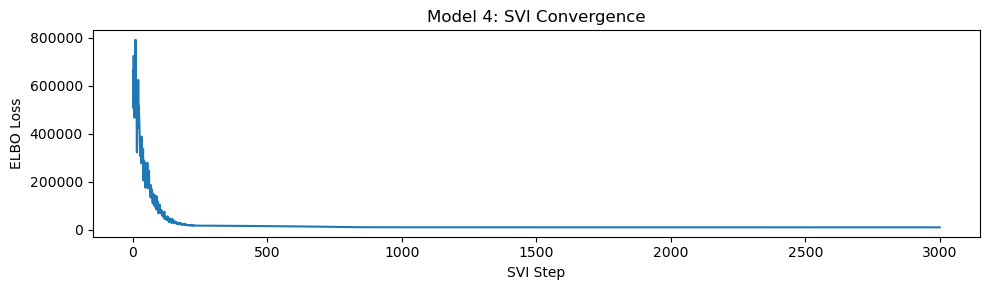

In [12]:
plt.figure(figsize=(10, 3))
plt.plot(losses)
plt.xlabel("SVI Step")
plt.ylabel("ELBO Loss")
plt.title("Model 4: SVI Convergence")
plt.tight_layout()
plt.show()

## 9. Posterior Predictive — Output N(μ, σ²)

### Why output N(μ, σ²) instead of just a point prediction?
The goal of Model 4 is not just to predict revenue — it is to contribute one informed opinion to a **Bayesian aggregator** that combines multiple models (budget-based, cast-based, genre-based, etc.).

The aggregator fuses models using the **product-of-experts / precision-weighted** formula:
- Each model contributes a mean (μ) and an uncertainty (σ)
- Models with lower σ (more confident) get more weight
- The fused prediction is: `μ_agg = σ_agg² · Σ(μᵢ / σᵢ²)`

If Model 4 only returned a point estimate, the aggregator would have no way to know how much to trust it. By returning the full predictive distribution, the model self-reports its confidence — and the aggregator weights it accordingly.

In [ ]:
N_SAMPLES = 500  # number of posterior samples drawn to approximate the predictive distribution

# Predictive draws N_SAMPLES sets of parameters from the guide (variational posterior),
# then runs the model forward to get a distribution over log-revenue
predictive = Predictive(model, guide=guide, num_samples=N_SAMPLES,
                        return_sites=["obs", "sigma_genre", "sigma_kw",
                                      "beta_genre", "beta_kw",
                                      "intercept", "sigma_obs"])

# Run posterior predictive on train and test sets (no gradient needed at inference time)
with torch.no_grad():
    post_tr = predictive(Xg_tr, Xk_tr, Xr_tr)
    post_te = predictive(Xg_te, Xk_te, Xr_te)

# obs shape: (N_SAMPLES, n_movies) — average over samples to get point estimate and uncertainty
mu_tr = post_tr["obs"].mean(0).numpy()   # posterior predictive mean per training movie
sd_tr = post_tr["obs"].std(0).numpy()    # posterior predictive std  per training movie

mu_te = post_te["obs"].mean(0).numpy()   # posterior predictive mean per test movie
sd_te = post_te["obs"].std(0).numpy()    # posterior predictive std  per test movie

print("Posterior predictive computed.")
print(f"Test  μ range: [{mu_te.min():.2f}, {mu_te.max():.2f}]")
print(f"Test  σ range: [{sd_te.min():.3f}, {sd_te.max():.3f}]")

## 10. Evaluate — RMSE on log-revenue

In [ ]:
from scipy.stats import norm
from sklearn.metrics import r2_score

rmse_train = np.sqrt(np.mean((mu_tr - y_tr.numpy())**2))
rmse_test  = np.sqrt(np.mean((mu_te - y_te.numpy())**2))

r2_train = r2_score(y_tr.numpy(), mu_tr)
r2_test  = r2_score(y_te.numpy(), mu_te)

log_lik = norm.logpdf(y_te.numpy(), loc=mu_te, scale=sd_te).mean()

print(f"RMSE (log-revenue) — Train : {rmse_train:.4f}")
print(f"RMSE (log-revenue) — Test  : {rmse_test:.4f}")
print(f"R²                 — Train : {r2_train:.4f}")
print(f"R²                 — Test  : {r2_test:.4f}")
print(f"Mean log-likelihood (test) : {log_lik:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_te.numpy(), mu_te, alpha=0.3, s=12, color='steelblue')
lo, hi = y_te.numpy().min(), y_te.numpy().max()
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='perfect')
ax.set_xlabel("Actual log-revenue")
ax.set_ylabel("Predicted μ")
ax.set_title(f"Model 4: Predicted vs Actual  (RMSE={rmse_test:.3f}, R²={r2_test:.3f})")
ax.legend()

ax = axes[1]
ax.hist(sd_te, bins=40, color='coral', edgecolor='white')
ax.set_xlabel("Predictive σ (log-revenue)")
ax.set_ylabel("Count")
ax.set_title("Predictive Uncertainty per Movie")

plt.tight_layout()
plt.show()

## 11. What Did the Model Learn? — Genre Weights

In [ ]:
# Extract genre weight samples from the posterior predictive object — shape (N_SAMPLES, N_GENRE)
beta_genre_samples = post_te["beta_genre"].numpy()

# Baseline = training mean revenue (2024 USD)
# exp(mean log-revenue) = geometric mean revenue of training movies
baseline_revenue = np.exp(y_tr.numpy().mean())
print(f"Training baseline revenue: ${baseline_revenue/1e6:.1f}M")

# Convert log-revenue betas → dollar effect relative to baseline
# If log-revenue changes by β, revenue changes by baseline * (exp(β) - 1)
# Transform each posterior sample so uncertainty propagates correctly
revenue_effect_samples = baseline_revenue * (np.exp(beta_genre_samples) - 1)  # (N_SAMPLES, N_GENRE)
revenue_effect_mean = revenue_effect_samples.mean(0).flatten()   # posterior mean $ effect per genre
revenue_effect_std  = revenue_effect_samples.std(0).flatten()    # posterior std  $ effect per genre

genre_weight_df = pd.DataFrame({
    'genre'         : TOP_GENRES,
    'mean_β'        : beta_genre_samples.mean(0).flatten(),      # keep raw β for reference
    'revenue_effect': revenue_effect_mean,
    'revenue_std'   : revenue_effect_std,
    'lower'         : revenue_effect_mean - 2 * revenue_effect_std,
    'upper'         : revenue_effect_mean + 2 * revenue_effect_std,
}).sort_values('revenue_effect', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['green' if m > 0 else 'red' for m in genre_weight_df['revenue_effect']]
# Error bars show ±2σ in revenue space — if bar crosses 0, that genre's effect is uncertain
ax.barh(genre_weight_df['genre'], genre_weight_df['revenue_effect'] / 1e6,
        xerr=2 * genre_weight_df['revenue_std'] / 1e6, color=colors, alpha=0.7,
        capsize=4, ecolor='gray')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel(f"Revenue effect vs baseline (${baseline_revenue/1e6:.0f}M train mean)  [$ millions]")
ax.set_title("Model 4: Posterior Genre Revenue Effects (±2σ)")
plt.tight_layout()
plt.show()

genre_weight_df[['genre', 'revenue_effect', 'revenue_std', 'lower', 'upper']].assign(
    **{c: genre_weight_df[c] / 1e6 for c in ['revenue_effect', 'revenue_std', 'lower', 'upper']}
).rename(columns=lambda c: c + '_$M' if c != 'genre' else c)

## 12. Keyword Topic Weights

In [ ]:
# Extract keyword topic weight samples — shape (N_SAMPLES, N_KW)
beta_kw_samples = post_te["beta_kw"].numpy()
beta_kw_mean = beta_kw_samples.mean(0).flatten()
beta_kw_std  = beta_kw_samples.std(0).flatten()

# Show top 5 keywords per SVD topic so we can interpret what each topic represents
feature_names = tfidf.get_feature_names_out()
components = svd.components_   # shape (N_KW, vocab_size) — each row is one topic

print("Top keywords per topic:")
for i in range(N_KEYWORD_TOPICS):
    top_kw = [feature_names[j] for j in components[i].argsort()[-5:][::-1]]
    sign   = "+" if beta_kw_mean[i] > 0 else "-"
    # β sign tells whether this topic's presence helps (+) or hurts (-) predicted revenue
    print(f"  Topic {i:2d} [{sign} β={beta_kw_mean[i]:+.3f}]: {', '.join(top_kw)}")

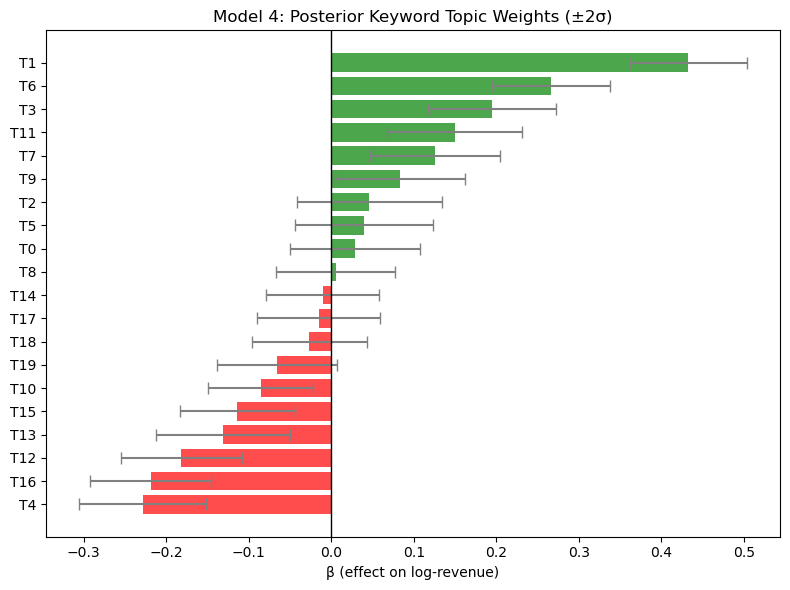

In [18]:
kw_topic_labels = [f"T{i}" for i in range(N_KEYWORD_TOPICS)]

kw_weight_df = pd.DataFrame({
    'topic'  : kw_topic_labels,
    'mean_β' : beta_kw_mean,
    'std_β'  : beta_kw_std,
}).sort_values('mean_β', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['green' if m > 0 else 'red' for m in kw_weight_df['mean_β']]
ax.barh(kw_weight_df['topic'], kw_weight_df['mean_β'],
        xerr=2 * kw_weight_df['std_β'], color=colors, alpha=0.7,
        capsize=4, ecolor='gray')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel("β (effect on log-revenue)")
ax.set_title("Model 4: Posterior Keyword Topic Weights (±2σ)")
plt.tight_layout()
plt.show()

## 13. Export Posterior Predictive — N(μ, σ²) per Movie

This is the output fed into the Bayesian aggregator (precision-weighted fusion).

In [ ]:
# Run posterior predictive on full train + test combined
all_movies = pd.concat([train, test], ignore_index=True)
Xg_all = torch.tensor(np.vstack([X_genre_tr, X_genre_te]))
Xk_all = torch.tensor(np.vstack([X_kw_tr, X_kw_te]))
Xr_all = torch.tensor(np.vstack([X_runtime_tr, X_runtime_te]))

with torch.no_grad():
    post_all = predictive(Xg_all, Xk_all, Xr_all)

mu_all = post_all["obs"].mean(0).numpy()
sd_all = post_all["obs"].std(0).numpy()

model4_output = pd.DataFrame({
    'id'             : all_movies['id'].values,
    'title'          : all_movies['title'].values,
    'log_revenue'    : all_movies['log_revenue'].values,
    'mu_genre'       : mu_all,
    'sigma_genre'    : sd_all,
    'precision_genre': 1.0 / (sd_all ** 2),
})

model4_output.to_csv(DATA_DIR / 'model4_posterior.csv', index=False)
print(f"Saved model4_posterior.csv — {model4_output.shape[0]} movies")
model4_output.head(10)

## 14. Summary

| Output | Meaning |
|--------|----------|
| `mu_genre` | Posterior mean log-revenue prediction from genre+keywords |
| `sigma_genre` | Posterior std — uncertainty of this model |
| `precision_genre` | `1/σ²` — weight in precision-weighted Bayesian fusion |

**Aggregator formula (product of experts):**
```
σ_agg² = 1 / Σ_i (1/σ_i²)
μ_agg  = σ_agg² · Σ_i (μ_i / σ_i²)
```
Model 4 contributes one term. High σ_genre → low weight in aggregation → model self-reports low confidence.

## 15. Predict Revenue for a New Movie

In [ ]:
def predict_revenue(genres: list, keywords: list, runtime_min: float):
    """
    Predict revenue for a new movie (all values in 2024 USD).

    Parameters
    ----------
    genres      : list of genre name strings, e.g. ["Action", "Adventure"]
    keywords    : list of keyword strings,    e.g. ["sequel", "superhero"]
    runtime_min : runtime in minutes
    """
    names = set(g.lower() for g in genres)
    x_genre = np.array([[
        1.0 if col.replace('genre_', '').replace('_', ' ') in names else 0.0
        for col in GENRE_COLS
    ]], dtype=np.float32)

    kw_string  = ' '.join(k.replace(' ', '_') for k in keywords)
    x_kw_tfidf = tfidf.transform([kw_string])
    x_kw_svd   = svd.transform(x_kw_tfidf)
    x_kw       = scaler_kw.transform(x_kw_svd).astype(np.float32)

    x_runtime = scaler_runtime.transform([[np.log(runtime_min)]]).astype(np.float32)

    Xg = torch.tensor(x_genre)
    Xk = torch.tensor(x_kw)
    Xr = torch.tensor(x_runtime)

    with torch.no_grad():
        samples = predictive(Xg, Xk, Xr)

    log_rev_samples = samples["obs"].squeeze().numpy()
    rev_samples     = np.exp(log_rev_samples)

    return {
        "median_2024_USD": np.median(rev_samples),
        "p5_2024_USD"    : np.percentile(rev_samples, 5),
        "p95_2024_USD"   : np.percentile(rev_samples, 95),
        "log_rev_mu"     : log_rev_samples.mean(),
        "log_rev_sigma"  : log_rev_samples.std(),
    }


example1 = predict_revenue(
    genres      = ["Action", "Adventure", "Science Fiction"],
    keywords    = ["sequel", "superhero", "marvel_comic", "3d"],
    runtime_min = 150,
)
print("Action/Sci-Fi blockbuster:")
print(f"  Median revenue : ${example1['median_2024_USD']/1e6:.0f}M (2024 USD)")
print(f"  90% interval  : ${example1['p5_2024_USD']/1e6:.0f}M – ${example1['p95_2024_USD']/1e6:.0f}M")
print(f"  log-rev μ±σ   : {example1['log_rev_mu']:.2f} ± {example1['log_rev_sigma']:.2f}")

print()
example2 = predict_revenue(
    genres      = ["Drama"],
    keywords    = ["independent_film", "woman_director"],
    runtime_min = 95,
)
print("Low-budget Drama:")
print(f"  Median revenue : ${example2['median_2024_USD']/1e6:.0f}M (2024 USD)")
print(f"  90% interval  : ${example2['p5_2024_USD']/1e6:.0f}M – ${example2['p95_2024_USD']/1e6:.0f}M")